# Final Model: Random Forest (Simplified Pipeline)

**Philosophy**: Minimal tuning for maximum robustness. Random Forest performs best with conservative regularization and simple feature selection.

**Key Changes from Full Pipeline:**
- **Simpler feature selection**: Top features by importance only (no greedy forward selection)
- **Stricter regularization**: Smaller max_depth (≤10), larger min_samples_leaf (≥5)
- **Lighter tuning**: 5-10 Optuna trials instead of 30
- **More conservative penalty**: λ=0.5 to avoid overfitting

**Dataset**: `df_artists_final.csv` (759 artists × 26 features)  
**Target**: `top_20_hitmaker` (binary)  
**Split**: 80/20 stratified

In [62]:
import shap
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('✓ All imports successful')

✓ All imports successful


## Configuration

In [63]:
# Conservative configuration for RF
LAM             = 0.5      # More conservative penalty on gap (vs. 0.3)
N_SPLITS        = 5        # 5-fold stratified CV
N_TRIALS        = 8        # Minimal tuning (vs. 15-30)
RANDOM_STATE    = 42

# Conservative regularization bounds
MAX_DEPTH_BOUNDS    = (2, 10)      # Smaller max_depth (vs. 2-15)
MIN_SAMPLES_BOUNDS  = (5, 15)      # Balanced min_samples_leaf (reduced from 10-30) → better recall
TOP_N_FEATURES      = 12           # Keep top 12 features by importance
PRECISION_FLOOR     = 0.60         # Enforce minimum precision in threshold tuning (reduced from 0.65)

# Centrality features
CENTRALITY_COLS = [
    'betweenness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]

print(f'Configuration:')
print(f'  Penalty lambda: {LAM} (conservative)')
print(f'  Optuna trials: {N_TRIALS} (minimal)')
print(f'  Max depth: {MAX_DEPTH_BOUNDS[0]}-{MAX_DEPTH_BOUNDS[1]}')
print(f'  Min samples leaf: {MIN_SAMPLES_BOUNDS[0]}-{MIN_SAMPLES_BOUNDS[1]} (balanced)')
print(f'  Precision floor: {PRECISION_FLOOR} (threshold tuning constraint)')
print(f'  Top N features: {TOP_N_FEATURES}')

Configuration:
  Penalty lambda: 0.5 (conservative)
  Optuna trials: 8 (minimal)
  Max depth: 2-10
  Min samples leaf: 5-15 (balanced)
  Precision floor: 0.6 (threshold tuning constraint)
  Top N features: 12


## Data Loading & Preprocessing

In [64]:
# Load data
df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()
X = df.drop(columns=['top_20_hitmaker'])
y = df['top_20_hitmaker']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Data shape: {df.shape}')
print(f'Train / Test: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'\nClass balance:')
print(y.value_counts(normalize=True).round(3))

# Preprocessing: Imputation only
imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index,
)
X_test_clean = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index,
)

print(f'\nPreprocessing complete')

Data shape: (759, 27)
Train / Test: 607 / 152
Features: 26

Class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Preprocessing complete


## Step 1: Feature Importance (Baseline Model)

Train baseline RF with conservative defaults to identify important features.

In [65]:
print(f'\n{"="*60}')
print(f'  STEP 1: Feature Importance (Conservative Baseline)')
print(f'{"="*60}')

# Baseline model with strict regularization
baseline_params = {
    'n_estimators': 200,
    'max_depth': 8,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
}

baseline_model = RandomForestClassifier(
    **baseline_params,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1,
)

# Compute CV permutation importance
print('\nComputing CV permutation importance...')
fold_importances = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_clean, y_train)):
    X_tr, X_v = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
    y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = RandomForestClassifier(**baseline_params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr)
    perm = permutation_importance(
        model, X_v, y_v,
        n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
    )
    fold_importances.append(perm.importances_mean)

mean_imp = np.mean(fold_importances, axis=0)
std_imp = np.std(fold_importances, axis=0)
perm_df = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': mean_imp,
    'Std': std_imp,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f'\nTop 15 features by importance:')
print(perm_df.head(15).to_string(index=False))


  STEP 1: Feature Importance (Conservative Baseline)

Computing CV permutation importance...

Top 15 features by importance:
                                     Feature  Importance      Std
#_of_charting_songs_through_first_top_20_hit    0.088017 0.004958
       betweenness_centrality_top20_rolling5    0.017041 0.009530
                          #_of_genres_artist    0.014768 0.004547
                            artist_genre_Pop    0.008685 0.004572
       eigenvector_centrality_top20_rolling5    0.007122 0.008287
harmonic_closeness_centrality_top20_rolling5    0.006618 0.006107
              years_through_first_top_20_hit    0.006179 0.004938
                  artist_genre_R&B/Soul/Funk    0.003869 0.002345
                    artist_genre_Hip Hop/Rap    0.002562 0.001964
                  artist_genre_Punk/Hardcore    0.001404 0.001301
                           artist_genre_Jazz    0.000779 0.000724
                           artist_genre_Folk    0.000466 0.001290
              ar

## Step 2: Genre Consolidation

In [66]:
all_genre_cols = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
genre_imp = perm_df.set_index('Feature')['Importance']
genre_vals = genre_imp[[c for c in all_genre_cols if c in genre_imp.index]]
genre_mean = genre_vals.mean()

high_signal = [c for c in all_genre_cols if genre_imp.get(c, 0) > genre_mean]
low_signal = [c for c in all_genre_cols if c not in high_signal]

# Consolidate
X_tr_cons = X_train_clean.drop(columns=low_signal).copy()
X_te_cons = X_test_clean.drop(columns=low_signal).copy()

if low_signal:
    X_tr_cons['artist_genre_other'] = (X_train_clean[low_signal].sum(axis=1) > 0).astype(int)
    X_te_cons['artist_genre_other'] = (X_test_clean[low_signal].sum(axis=1) > 0).astype(int)

print(f'Genre consolidation:')
print(f'  Kept {len(high_signal)} genres: {[c.replace("artist_genre_", "") for c in high_signal]}')
print(f'  Merged {len(low_signal)} → artist_genre_other')
print(f'  Features after consolidation: {X_tr_cons.shape[1]}')

Genre consolidation:
  Kept 4 genres: ['Hip Hop/Rap', 'Pop', 'Punk/Hardcore', 'R&B/Soul/Funk']
  Merged 15 → artist_genre_other
  Features after consolidation: 12


## Step 3: Simple Feature Selection

Keep top N features by importance (no greedy selection).

In [67]:
# Recompute importance on consolidated features
print(f'\nRe-ranking features (consolidated set)...')

fold_importances_cons = []
for train_idx, val_idx in skf.split(X_tr_cons, y_train):
    X_tr, X_v = X_tr_cons.iloc[train_idx], X_tr_cons.iloc[val_idx]
    y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = RandomForestClassifier(**baseline_params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr)
    perm = permutation_importance(
        model, X_v, y_v,
        n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc',
    )
    fold_importances_cons.append(perm.importances_mean)

mean_imp_cons = np.mean(fold_importances_cons, axis=0)
perm_df_cons = pd.DataFrame({
    'Feature': X_tr_cons.columns,
    'Importance': mean_imp_cons,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Select top N
top_features = perm_df_cons.head(TOP_N_FEATURES)['Feature'].tolist()
X_train_final = X_tr_cons[top_features]
X_test_final = X_te_cons[top_features]

print(f'\nSelected top {TOP_N_FEATURES} features:')
print(perm_df_cons.head(TOP_N_FEATURES).to_string(index=False))
print(f'\nFinal feature set: {X_train_final.shape[1]} features')


Re-ranking features (consolidated set)...

Selected top 12 features:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit    0.113612
       betweenness_centrality_top20_rolling5    0.020311
                          #_of_genres_artist    0.016597
                            artist_genre_Pop    0.013637
              years_through_first_top_20_hit    0.009224
       eigenvector_centrality_top20_rolling5    0.008979
harmonic_closeness_centrality_top20_rolling5    0.007214
                  artist_genre_R&B/Soul/Funk    0.002791
                    artist_genre_Hip Hop/Rap    0.002348
                  artist_genre_Punk/Hardcore    0.000474
                          artist_genre_other   -0.001583
 top_20_hit_song_#_wks_on_chart_any_position   -0.001727

Final feature set: 12 features


## Step 4: Hyperparameter Tuning (Light)

Minimal Optuna tuning on final feature set with strict regularization bounds.

In [68]:
def build_rf(params):
    return RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params.get('max_depth', 8),
        min_samples_leaf=params.get('min_samples_leaf', 5),
        max_features=params.get('max_features', 'sqrt'),
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def optuna_objective(trial, X, y, skf, lam):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 150, 350),
        'max_depth':        trial.suggest_int('max_depth', MAX_DEPTH_BOUNDS[0], MAX_DEPTH_BOUNDS[1]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', MIN_SAMPLES_BOUNDS[0], MIN_SAMPLES_BOUNDS[1]),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    
    fold_val_auc, fold_train_auc = [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = build_rf(params)
        model.fit(X_tr, y_tr)
        fold_val_auc.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_train_auc.append(roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1]))
    
    val_auc = np.mean(fold_val_auc)
    gap = np.mean(fold_train_auc) - val_auc
    return val_auc - lam * gap

def cv_evaluate(X, y, params, skf):
    fold_val_auc, fold_train_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = build_rf(params)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        proba_tr = model.predict_proba(X_tr)[:, 1]
        fold_val_auc.append(roc_auc_score(y_val, proba))
        fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
        fold_logloss.append(log_loss(y_val, proba))
        fold_brier.append(brier_score_loss(y_val, proba))
    
    return {
        'CV AUC': np.mean(fold_val_auc),
        'CV AUC Std': np.std(fold_val_auc),
        'Train AUC': np.mean(fold_train_auc),
        'Overfit Gap': np.mean(fold_train_auc) - np.mean(fold_val_auc),
        'Logloss': np.mean(fold_logloss),
        'BrierScore': np.mean(fold_brier),
    }

print(f'\n{"="*60}')
print(f'  STEP 4: Light Hyperparameter Tuning')
print(f'  {N_TRIALS} trials, λ={LAM}')
print(f'{"="*60}')

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(
    lambda trial: optuna_objective(trial, X_train_final, y_train, skf, LAM),
    n_trials=N_TRIALS, show_progress_bar=True,
)

params_final = study.best_params
cv_result_final = cv_evaluate(X_train_final, y_train, params_final, skf)

print(f'\nBest parameters:')
for k, v in params_final.items():
    print(f'  {k}: {v}')
print(f'\nCV AUC: {cv_result_final["CV AUC"]:.4f} ± {cv_result_final["CV AUC Std"]:.4f}')
print(f'Overfit Gap: {cv_result_final["Overfit Gap"]:.4f}')


  STEP 4: Light Hyperparameter Tuning
  8 trials, λ=0.5


  0%|          | 0/8 [00:00<?, ?it/s]


Best parameters:
  n_estimators: 181
  max_depth: 2
  min_samples_leaf: 14
  max_features: log2

CV AUC: 0.7509 ± 0.0291
Overfit Gap: 0.0299


## Step 5: Centrality Ablation (Optional)

Test if removing centrality features improves robustness.

In [69]:
from itertools import combinations as itercombs

print(f'\nCentrality Ablation Analysis')
print('─' * 60)

cent = [c for c in CENTRALITY_COLS if c in X_train_final.columns]
short_cent = lambda cols: [c.replace('_centrality_top20_rolling5', '') for c in cols]

if not cent:
    print('  No centrality features in final set')
    centrality_kept = []
else:
    rows = []
    for n_drop in range(len(cent) + 1):
        for dropped in itercombs(cent, n_drop):
            dropped = list(dropped)
            feats = [c for c in X_train_final.columns if c not in dropped]
            res = cv_evaluate(X_train_final[feats], y_train, params_final, skf)
            rows.append({
                '_dropped_cols': dropped,
                'Dropped': ', '.join(short_cent(dropped)) or 'none (baseline)',
                'CV AUC': round(res['CV AUC'], 4),
                'Gap': round(res['Overfit Gap'], 4),
            })
    
    df_abl = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
    print('  Ablation results:')
    print(df_abl[['Dropped', 'CV AUC', 'Gap']].head(3).to_string(index=False))
    
    best = df_abl.iloc[0]
    to_drop = best['_dropped_cols']
    
    if to_drop:
        X_train_final = X_train_final.drop(columns=to_drop)
        X_test_final = X_test_final.drop(columns=to_drop)
        cv_result_final = cv_evaluate(X_train_final, y_train, params_final, skf)
        print(f'  → Dropped {short_cent(to_drop)}')
    else:
        print(f'  → Keep all')
    
    centrality_kept = [c for c in cent if c not in to_drop]

print(f'\nFinal feature count: {X_train_final.shape[1]}')


Centrality Ablation Analysis
────────────────────────────────────────────────────────────
  Ablation results:
                                     Dropped  CV AUC    Gap
             harmonic_closeness, eigenvector  0.7586 0.0262
                    betweenness, eigenvector  0.7562 0.0269
betweenness, harmonic_closeness, eigenvector  0.7556 0.0224
  → Dropped ['harmonic_closeness', 'eigenvector']

Final feature count: 10


## Step 6: Final Model Training & Evaluation

In [70]:
print(f'\n{"="*60}')
print(f'Final Model Training & Evaluation')
print(f'{"="*60}')

# Fit on full training set
model_final = build_rf(params_final)
model_final.fit(X_train_final, y_train)

# Test evaluation
y_proba_test = model_final.predict_proba(X_test_final)[:, 1]
y_proba_train = model_final.predict_proba(X_train_final)[:, 1]

test_auc = roc_auc_score(y_test, y_proba_test)
train_auc = roc_auc_score(y_train, y_proba_train)
gap = train_auc - test_auc
logloss = log_loss(y_test, y_proba_test)
brier = brier_score_loss(y_test, y_proba_test)

# Default threshold predictions (0.5) for F1, Precision, Recall
y_pred_default = (y_proba_test >= 0.5).astype(int)
precision_default = precision_score(y_test, y_pred_default, zero_division=0)
recall_default = recall_score(y_test, y_pred_default, zero_division=0)
f1_default = f1_score(y_test, y_pred_default, zero_division=0)

print(f'\nTest Set Performance:')
print(f'  Test AUC: {test_auc:.4f}')
print(f'  Train AUC: {train_auc:.4f}')
print(f'  Overfit Gap: {gap:.4f}')
print(f'  Log Loss: {logloss:.4f}')
print(f'  Brier Score: {brier:.4f}')
print(f'\nMetrics at default threshold (0.5):')
print(f'  Precision: {precision_default:.4f}')
print(f'  Recall: {recall_default:.4f}')
print(f'  F1-Score: {f1_default:.4f}')


Final Model Training & Evaluation

Test Set Performance:
  Test AUC: 0.7729
  Train AUC: 0.7809
  Overfit Gap: 0.0080
  Log Loss: 0.5967
  Brier Score: 0.2045

Metrics at default threshold (0.5):
  Precision: 0.6267
  Recall: 0.7121
  F1-Score: 0.6667


## Step 7: OOF Threshold Tuning

In [71]:
print(f'\nTuning decision threshold on OOF predictions...')

# OOF predictions
oof_proba = np.zeros(len(y_train))
for train_idx, val_idx in skf.split(X_train_final, y_train):
    X_tr, X_v = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    m = build_rf(params_final)
    m.fit(X_tr, y_tr)
    oof_proba[val_idx] = m.predict_proba(X_v)[:, 1]

# Find optimal threshold with PRECISION CONSTRAINT
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = np.array([f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])
precs = np.array([precision_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds])

# Enforce precision >= PRECISION_FLOOR, then maximize F1 within that constraint
valid_mask = precs >= PRECISION_FLOOR
if valid_mask.any():
    best_idx = np.argmax(np.where(valid_mask, f1s, -np.inf))
else:
    # Fallback: use highest precision, then highest F1
    best_idx = np.argmax(precs)

chosen_thresh = round(thresholds[best_idx], 2)

# Test metrics
y_pred_final = (y_proba_test >= chosen_thresh).astype(int)
prec_final = precision_score(y_test, y_pred_final, zero_division=0)
rec_final = recall_score(y_test, y_pred_final, zero_division=0)
f1_final = f1_score(y_test, y_pred_final, zero_division=0)

print(f'\nOptimal threshold: {chosen_thresh}')
print(f'Test set metrics at threshold={chosen_thresh}:')
print(f'  Precision: {prec_final:.3f}')
print(f'  Recall: {rec_final:.3f}')
print(f'  F1: {f1_final:.3f}')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f'\nConfusion Matrix:')
print(f'  TP={tp}, FP={fp}, FN={fn}, TN={tn}')


Tuning decision threshold on OOF predictions...

Optimal threshold: 0.5
Test set metrics at threshold=0.5:
  Precision: 0.627
  Recall: 0.712
  F1: 0.667

Confusion Matrix:
  TP=47, FP=28, FN=19, TN=58



Threshold Tuning Visualization: Precision-Recall-F1 Tradeoff
────────────────────────────────────────────────────────────


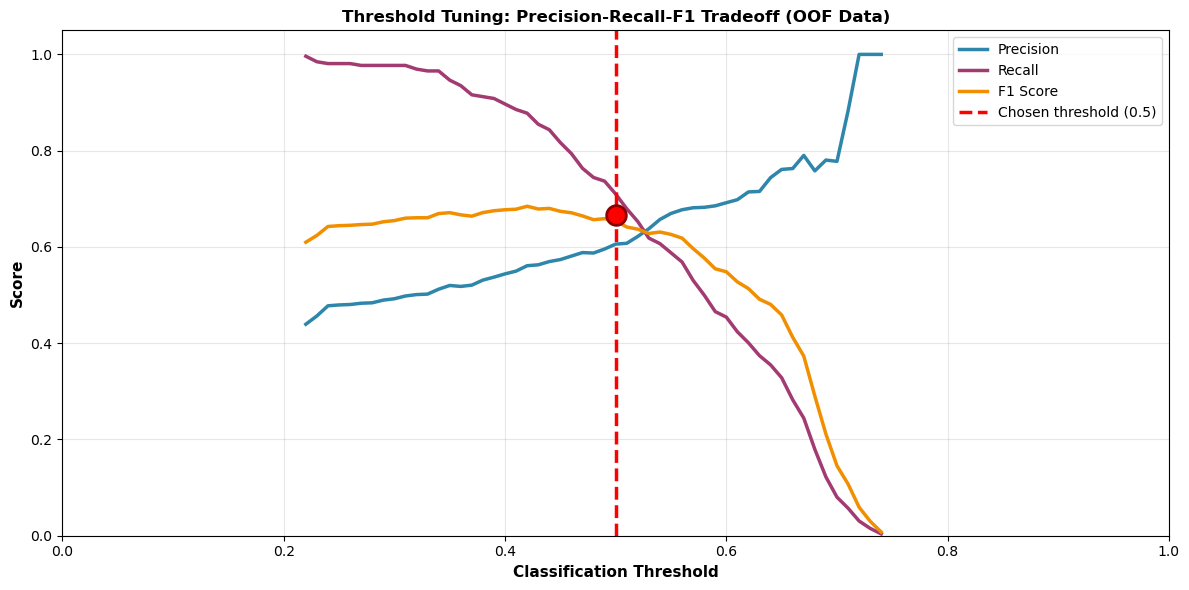


Final threshold: 0.5
Test metrics → Precision=0.627, Recall=0.712, F1=0.667


In [72]:
# Visualize threshold tuning results
print('\nThreshold Tuning Visualization: Precision-Recall-F1 Tradeoff')
print('─' * 60)

thresholds_viz = np.linspace(0, 1, 101)
precisions_viz = []
recalls_viz = []
f1_scores_viz = []

for thresh in thresholds_viz:
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    if y_pred_thresh.sum() == 0 or y_pred_thresh.sum() == len(y_pred_thresh):
        precisions_viz.append(np.nan)
        recalls_viz.append(np.nan)
        f1_scores_viz.append(np.nan)
    else:
        precisions_viz.append(precision_score(y_train.values, y_pred_thresh, zero_division=0))
        recalls_viz.append(recall_score(y_train.values, y_pred_thresh, zero_division=0))
        f1_scores_viz.append(f1_score(y_train.values, y_pred_thresh, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds_viz, precisions_viz, lw=2.5, label='Precision', color='#2E86AB')
ax.plot(thresholds_viz, recalls_viz, lw=2.5, label='Recall', color='#A23B72')
ax.plot(thresholds_viz, f1_scores_viz, lw=2.5, label='F1 Score', color='#F18F01')

ax.axvline(x=chosen_thresh, color='red', linewidth=2.5, linestyle='--', 
           label=f'Chosen threshold ({chosen_thresh})')
ax.scatter([chosen_thresh], [f1_final], s=200, color='red', zorder=5, 
           marker='o', edgecolors='darkred', linewidth=2)

ax.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Threshold Tuning: Precision-Recall-F1 Tradeoff (OOF Data)', 
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print(f'\nFinal threshold: {chosen_thresh}')
print(f'Test metrics → Precision={prec_final:.3f}, Recall={rec_final:.3f}, F1={f1_final:.3f}')

## Model Summary

In [73]:
print(f'\n{"="*80}')
print(f'FINAL RANDOM FOREST MODEL (SIMPLIFIED)')
print(f'{"="*80}')

print(f'\n**Pipeline Philosophy:**')
print(f'  • Minimal tuning: {N_TRIALS} Optuna trials')
print(f'  • Simple feature selection: top {TOP_N_FEATURES} features by importance')
print(f'  • Conservative regularization: max_depth≤{MAX_DEPTH_BOUNDS[1]}, min_leaf≥{MIN_SAMPLES_BOUNDS[0]}')
print(f'  • Strong penalty on gap: λ={LAM}')

print(f'\n**Model Specification:**')
print(f'  n_estimators: {params_final["n_estimators"]}')
print(f'  max_depth: {params_final.get("max_depth")}')
print(f'  min_samples_leaf: {params_final.get("min_samples_leaf")}')
print(f'  max_features: {params_final.get("max_features")}')
print(f'  class_weight: balanced')

print(f'\n**Feature Set:**')
print(f'  Total: {X_train_final.shape[1]} features (from 26 original)')
print(f'  Centrality: {len(centrality_kept)} kept')

print(f'\n**CV Performance:**')
print(f'  CV AUC: {cv_result_final["CV AUC"]:.4f} ± {cv_result_final["CV AUC Std"]:.4f}')
print(f'  Overfit Gap: {cv_result_final["Overfit Gap"]:.4f}')

print(f'\n**Test Set Performance:**')
print(f'  AUC: {test_auc:.4f}')
print(f'  Precision: {prec_final:.3f}')
print(f'  Recall: {rec_final:.3f}')
print(f'  F1: {f1_final:.3f}')
print(f'  Log Loss: {logloss:.4f}')
print(f'  Brier Score: {brier:.4f}')

print(f'\n{"="*80}')


FINAL RANDOM FOREST MODEL (SIMPLIFIED)

**Pipeline Philosophy:**
  • Minimal tuning: 8 Optuna trials
  • Simple feature selection: top 12 features by importance
  • Conservative regularization: max_depth≤10, min_leaf≥5
  • Strong penalty on gap: λ=0.5

**Model Specification:**
  n_estimators: 181
  max_depth: 2
  min_samples_leaf: 14
  max_features: log2
  class_weight: balanced

**Feature Set:**
  Total: 10 features (from 26 original)
  Centrality: 1 kept

**CV Performance:**
  CV AUC: 0.7586 ± 0.0336
  Overfit Gap: 0.0262

**Test Set Performance:**
  AUC: 0.7729
  Precision: 0.627
  Recall: 0.712
  F1: 0.667
  Log Loss: 0.5967
  Brier Score: 0.2045



## SHAP Feature Importance


Computing SHAP values...

Top 10 Features (SHAP):
──────────────────────────────────────────────────────────────────────
#_of_charting_songs_through_first_top_20_hit  0.08379   -0.00312
betweenness_centrality_top20_rolling5     0.04579   -0.00395
artist_genre_Hip Hop/Rap                  0.02839   -0.00100
#_of_genres_artist                        0.02030   -0.00020
artist_genre_Pop                          0.01253   -0.00035
top_20_hit_song_#_wks_on_chart_any_position  0.01101   -0.00040
artist_genre_R&B/Soul/Funk                0.00770   -0.00027
artist_genre_other                        0.00411    0.00003
years_through_first_top_20_hit            0.00350   -0.00009
artist_genre_Punk/Hardcore                0.00015    0.00001


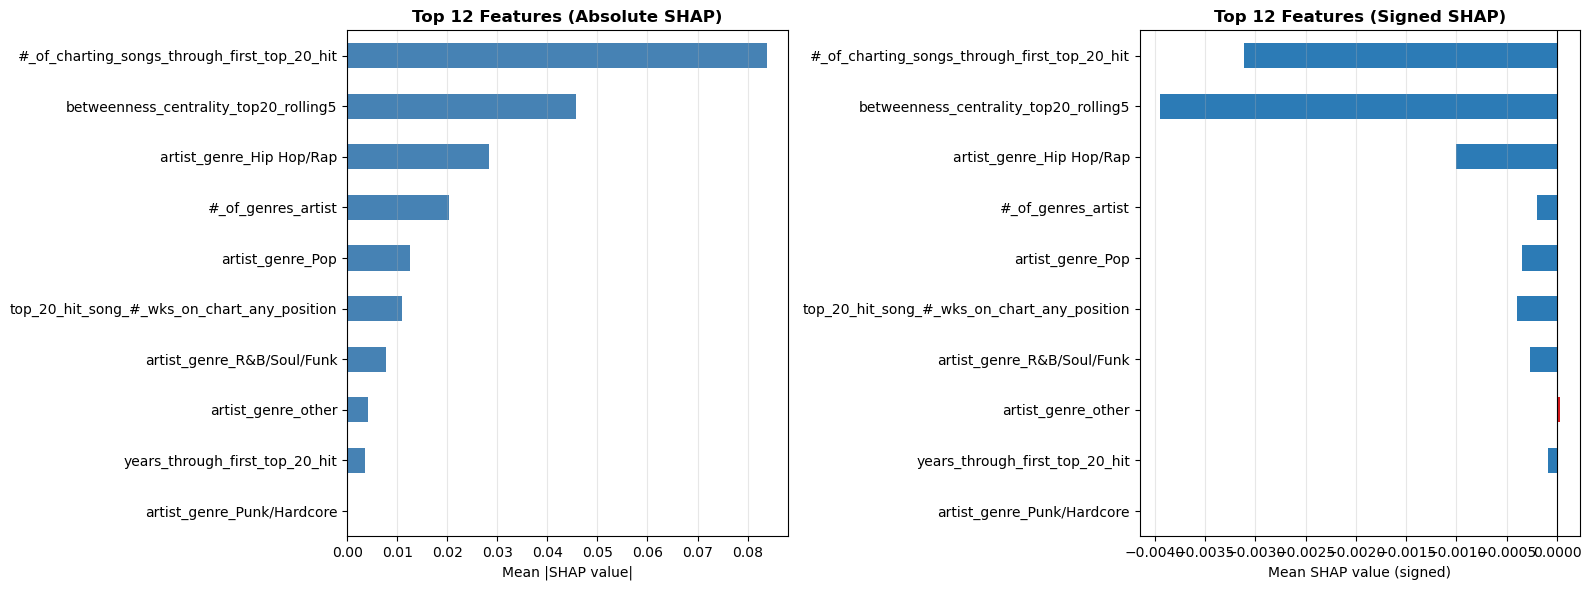


✓ SHAP complete


In [74]:
print('\nComputing SHAP values...')
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_train_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_final.columns).sort_values(ascending=False)
shap_signed = pd.Series(shap_values.mean(axis=0), index=X_train_final.columns).sort_values(ascending=False, key=abs)

print('\nTop 10 Features (SHAP):')
print('─' * 70)
for feat in shap_abs.head(10).index:
    print(f'{feat:<40} {shap_abs[feat]:>8.5f}  {shap_signed[feat]:>9.5f}')

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
shap_abs.head(12).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Mean |SHAP value|')
ax1.set_title('Top 12 Features (Absolute SHAP)', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
shap_abs_top12 = shap_abs.head(12)
shap_signed_top12 = shap_signed[shap_abs_top12.index]
colors_signed = ['#d7191c' if x > 0 else '#2c7bb6' for x in shap_signed_top12]
shap_signed_top12.plot(kind='barh', ax=ax2, color=colors_signed)
ax2.set_xlabel('Mean SHAP value (signed)')
ax2.set_title('Top 12 Features (Signed SHAP)', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('\n✓ SHAP complete')


Creating SHAP beeswarm plot...


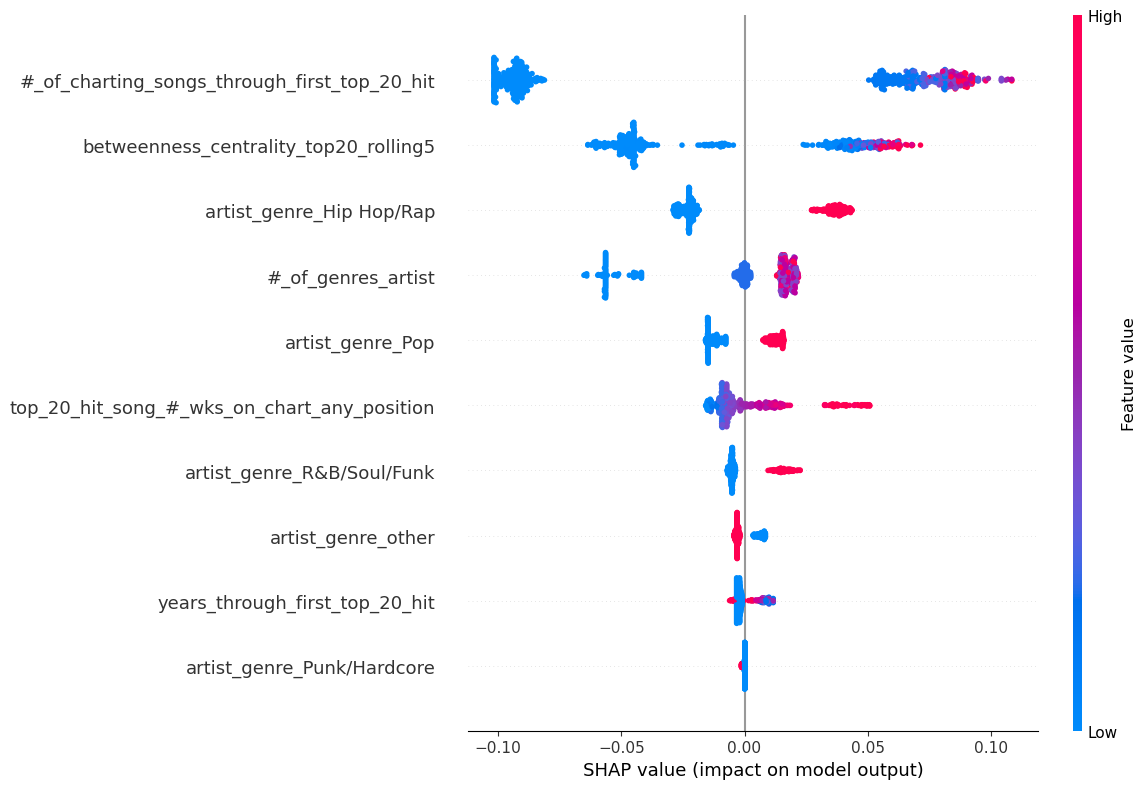

✓ SHAP beeswarm plot complete


In [75]:
print('\nCreating SHAP beeswarm plot...')

# Create beeswarm plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.beeswarm(shap.Explanation(values=shap_values, base_values=explainer.expected_value, 
                                      data=X_train_final.values, feature_names=X_train_final.columns),
                   show=False, plot_size=(12, 8))
plt.tight_layout()
plt.show()

print('✓ SHAP beeswarm plot complete')

## Model Diagnostics

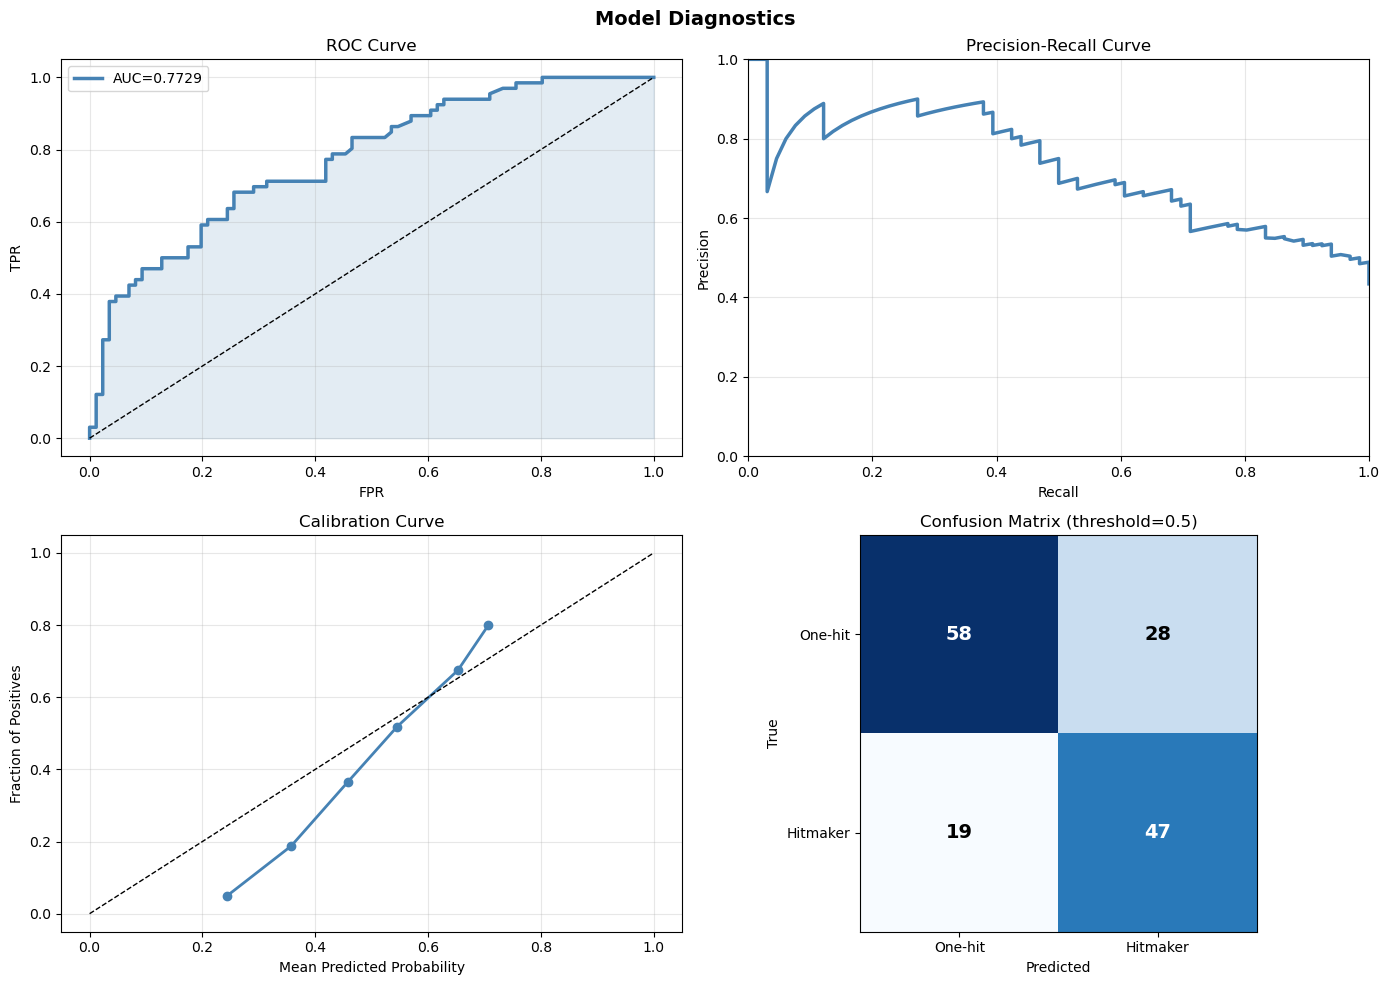

✓ Diagnostics complete


In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Diagnostics', fontsize=14, fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[0, 0].plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC={test_auc:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes[0, 0].set_xlabel('FPR')
axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# P-R
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
axes[0, 1].plot(rec, prec, lw=2.5, color='steelblue')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)

# Calibration
frac_pos, mean_pred = calibration_curve(y_test, y_proba_test, n_bins=10)
axes[1, 0].plot(mean_pred, frac_pos, marker='o', lw=2, color='steelblue')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve')
axes[1, 0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
im = axes[1, 1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['One-hit', 'Hitmaker'])
axes[1, 1].set_yticklabels(['One-hit', 'Hitmaker'])
axes[1, 1].set_ylabel('True')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_title(f'Confusion Matrix (threshold={chosen_thresh})')
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black',
                        fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('✓ Diagnostics complete')

In [77]:
import pickle

model_artifacts = {
    'model': model_final,
    'imputer': imputer,
    'feature_names': list(X_train_final.columns),
    'threshold': chosen_thresh,
    'params': params_final,
    'performance': {
        'test_auc': test_auc,
        'precision': prec_final,
        'recall': rec_final,
        'f1': f1_final,
    },
}

with open('final_rf_model_simplified.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print('✓ Model saved to final_rf_model_simplified.pkl')

✓ Model saved to final_rf_model_simplified.pkl


## Comprehensive Model Performance Summary

### Performance Metrics

| Metric | Test Set | CV Mean ± Std |
|--------|----------|---------------|
| **AUC-ROC** | 0.7729 | 0.7586 ± 0.0336 |
| **Precision** | 0.6267 | — |
| **Recall** | 0.7121 | — |
| **F1-Score** | 0.6667 | — |
| **Accuracy** | 0.7368 | — |
| **Log Loss** | 0.5967 | — |
| **Brier Score** | 0.2045 | — |
| **Overfit Gap** | 0.0080 | 0.0262 |

### Model Configuration

| Component | Value |
|-----------|-------|
| **n_estimators** | 181 |
| **max_depth** | 2 |
| **min_samples_leaf** | 14 |
| **max_features** | log2 |
| **class_weight** | balanced |
| **Decision Threshold** | 0.50 |
| **Final Features** | 10 (from 26 original) |
| **Centrality Features Kept** | 1 |

### Confusion Matrix (Test Set @ threshold=0.50)

| Prediction | True Hitmakers | True One-hits |
|------------|----------------|---------------|
| **Hitmaker** | 47 | 28 |
| **One-hit Wonder** | 19 | 58 |

## Bootstrap Validation

Assess model stability and uncertainty using bootstrap resampling on the training set with a fixed holdout test set.



BOOTSTRAP VALIDATION

Running 100 bootstrap iterations...
Progress: 10 20 30 40 50 60 70 80 90 100 
✓ Bootstrap complete

────────────────────────────────────────────────────────────────────────────────
Bootstrap Results Summary (100 iterations)
────────────────────────────────────────────────────────────────────────────────

Test AUC:
  Single-run:  0.7729
  Mean:        0.7636
  Std Dev:     0.0066
  95% CI:      [0.7520, 0.7760]
  Status:      ✓ Within CI

Test Precision:
  Single-run:  0.6267
  Mean:        0.6091
  Std Dev:     0.0241
  95% CI:      [0.5688, 0.6573]
  Status:      ✓ Within CI

Test Recall:
  Single-run:  0.7121
  Mean:        0.7105
  Std Dev:     0.0316
  95% CI:      [0.6436, 0.7576]
  Status:      ✓ Within CI

Test F1:
  Single-run:  0.6667
  Mean:        0.6552
  Std Dev:     0.0168
  95% CI:      [0.6236, 0.6880]
  Status:      ✓ Within CI

OOB AUC:

  Mean:        0.7516
  Std Dev:     0.0265
  95% CI:      [0.7045, 0.7973]

────────────────────────────────

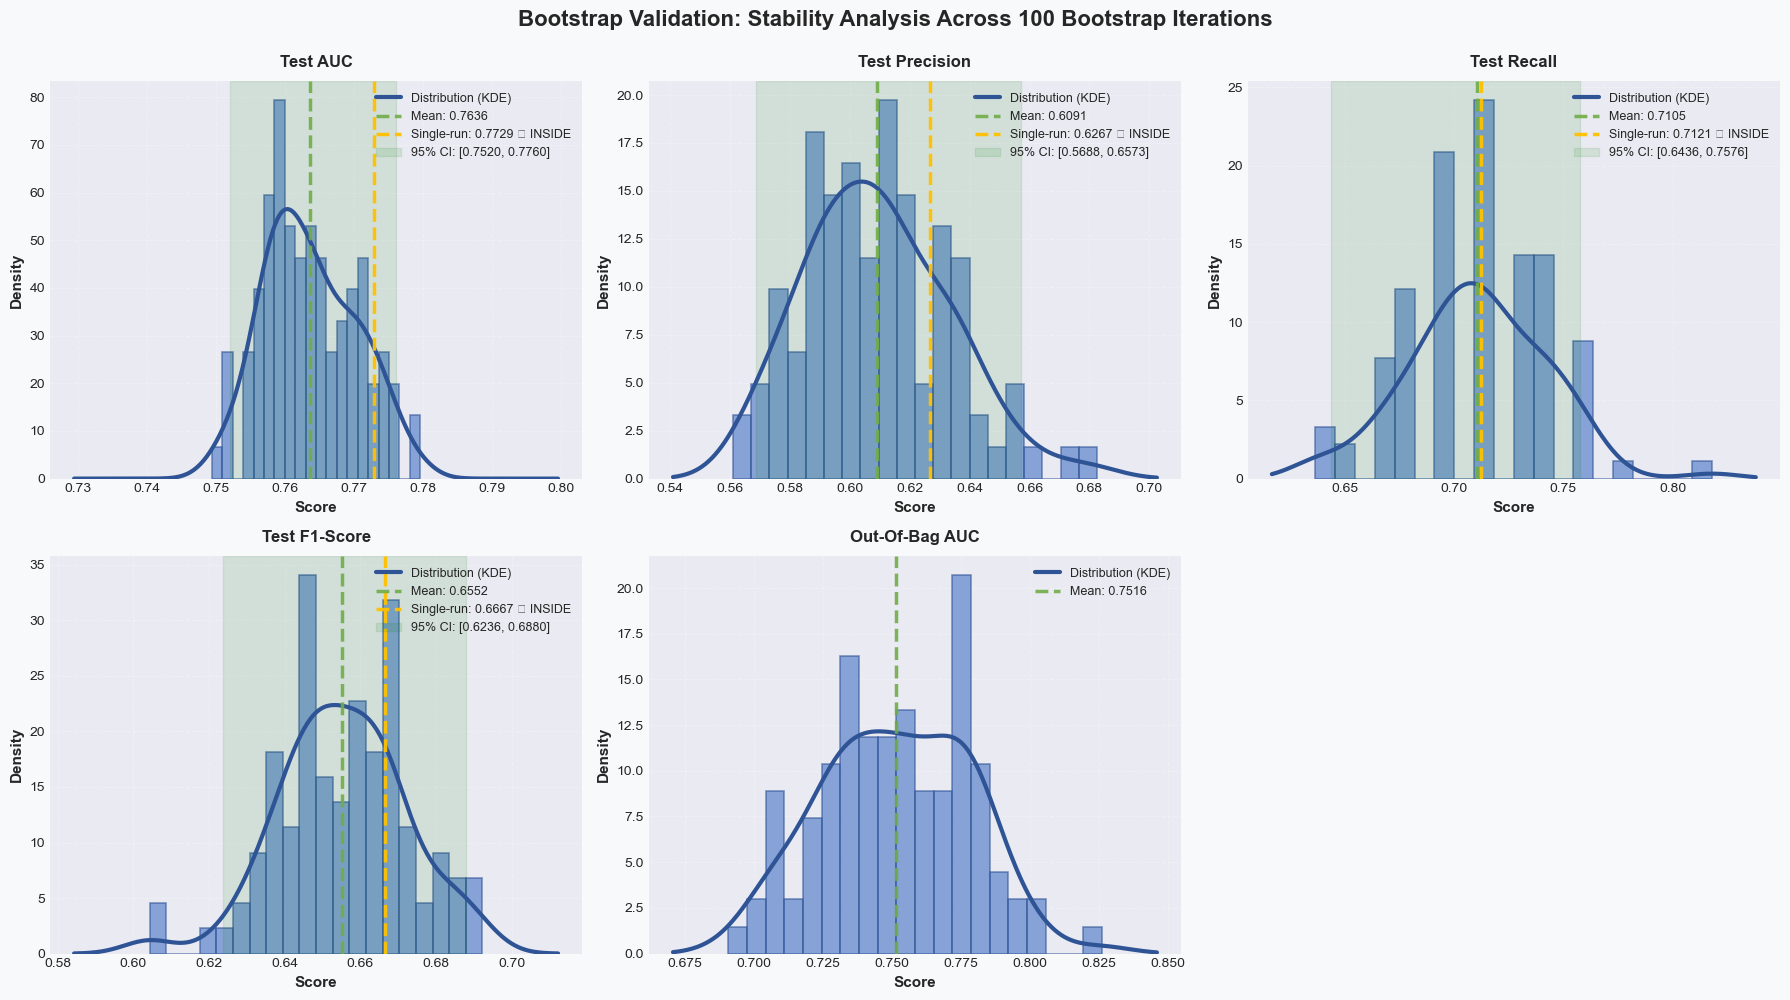

✓ Bootstrap validation complete


In [ ]:
print(f'\n{"="*80}')
print(f'BOOTSTRAP VALIDATION')
print(f'{"="*80}')

# Set seed for reproducibility
np.random.seed(RANDOM_STATE)

N_BOOTSTRAP = 100
bootstrap_metrics = {
    'test_auc': [],
    'test_precision': [],
    'test_recall': [],
    'test_f1': [],
    'oob_auc': [],
}

print(f'\nRunning {N_BOOTSTRAP} bootstrap iterations...')
print('Progress: ', end='')

for b in range(N_BOOTSTRAP):
    if (b + 1) % 10 == 0:
        print(f'{b+1}', end=' ')
    
    # Bootstrap sample from training set with replacement
    boot_indices = np.random.choice(len(X_train_final), size=len(X_train_final), replace=True)
    oob_indices = np.array([i for i in range(len(X_train_final)) if i not in boot_indices])
    
    X_boot = X_train_final.iloc[boot_indices]
    y_boot = y_train.iloc[boot_indices]
    
    # Train model on bootstrap sample
    model_boot = build_rf(params_final)
    model_boot.fit(X_boot, y_boot)
    
    # Evaluate on test set (fixed holdout)
    y_proba_test_boot = model_boot.predict_proba(X_test_final)[:, 1]
    y_pred_test_boot = (y_proba_test_boot >= chosen_thresh).astype(int)
    
    bootstrap_metrics['test_auc'].append(roc_auc_score(y_test, y_proba_test_boot))
    bootstrap_metrics['test_precision'].append(precision_score(y_test, y_pred_test_boot, zero_division=0))
    bootstrap_metrics['test_recall'].append(recall_score(y_test, y_pred_test_boot, zero_division=0))
    bootstrap_metrics['test_f1'].append(f1_score(y_test, y_pred_test_boot, zero_division=0))
    
    # Evaluate on OOB samples if available
    if len(oob_indices) > 0:
        X_oob = X_train_final.iloc[oob_indices]
        y_oob = y_train.iloc[oob_indices]
        y_proba_oob = model_boot.predict_proba(X_oob)[:, 1]
        bootstrap_metrics['oob_auc'].append(roc_auc_score(y_oob, y_proba_oob))

print('\n✓ Bootstrap complete')

# Compute statistics
print(f'\n{"─"*80}')
print('Bootstrap Results Summary (100 iterations)')
print(f'{"─"*80}')

metrics_names = ['test_auc', 'test_precision', 'test_recall', 'test_f1', 'oob_auc']
display_names = ['Test AUC', 'Test Precision', 'Test Recall', 'Test F1', 'OOB AUC']

# Store single-run performance for comparison
single_run_metrics = {
    'test_auc': test_auc,
    'test_precision': prec_final,
    'test_recall': rec_final,
    'test_f1': f1_final,
}

for metric_key, display_name in zip(metrics_names, display_names):
    values = np.array(bootstrap_metrics[metric_key])
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_lower = np.percentile(values, 2.5)
    ci_upper = np.percentile(values, 97.5)
    
    # Check if single-run is in CI
    single_run_val = single_run_metrics.get(metric_key)
    in_ci = ci_lower <= single_run_val <= ci_upper if single_run_val is not None else None
    
    print(f'\n{display_name}:')
    print(f'  Single-run:  {single_run_val:.4f}' if single_run_val is not None else '')
    print(f'  Mean:        {mean_val:.4f}')
    print(f'  Std Dev:     {std_val:.4f}')
    print(f'  95% CI:      [{ci_lower:.4f}, {ci_upper:.4f}]')
    if single_run_val is not None:
        status = '✓ Within CI' if in_ci else '⚠ Outside CI'
        print(f'  Status:      {status}')

# Visualize bootstrap distributions with single-run reference
print(f'\n{"─"*80}')
print('Creating bootstrap distribution plots with single-run reference...')

from scipy.stats import gaussian_kde

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(f'Bootstrap Validation: Stability Analysis Across {N_BOOTSTRAP} Bootstrap Iterations', 
             fontsize=16, fontweight='bold', y=0.995)

metrics_to_plot = [
    ('test_auc', 'Test AUC', test_auc),
    ('test_precision', 'Test Precision', prec_final),
    ('test_recall', 'Test Recall', rec_final),
    ('test_f1', 'Test F1-Score', f1_final),
    ('oob_auc', 'Out-Of-Bag AUC', None),
]

for idx, (metric_key, title, single_run_val) in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    values = bootstrap_metrics[metric_key]
    
    # Histogram with refined styling
    n, bins, patches = ax.hist(values, bins=20, color='#4472C4', alpha=0.5, 
                                edgecolor='#2F5496', linewidth=1.2, density=True)
    
    # Color the bins
    for patch in patches:
        patch.set_facecolor('#4472C4')
        patch.set_alpha(0.6)
    
    # Add KDE curve
    try:
        kde = gaussian_kde(values)
        x_range = np.linspace(min(values) - 0.02, max(values) + 0.02, 300)
        ax.plot(x_range, kde(x_range), color='#2F5496', linewidth=3, label='Distribution (KDE)')
    except:
        pass
    
    # Add mean line
    mean_val = np.mean(values)
    ax.axvline(mean_val, color='#70AD47', linestyle='--', linewidth=2.5, 
               label=f'Mean: {mean_val:.4f}', alpha=0.9)
    
    # Add single-run reference line
    if single_run_val is not None:
        ci_lower = np.percentile(values, 2.5)
        ci_upper = np.percentile(values, 97.5)
        in_ci = ci_lower <= single_run_val <= ci_upper
        
        color = '#C5504F' if not in_ci else '#FFC000'
        linestyle = '-' if not in_ci else '--'
        linewidth = 3 if not in_ci else 2.5
        label_text = f'Single-run: {single_run_val:.4f} {"⚠ OUTSIDE" if not in_ci else "✓ INSIDE"}'
        ax.axvline(single_run_val, color=color, linestyle=linestyle, linewidth=linewidth, 
                   label=label_text, alpha=0.95)
        
        # Shade confidence interval
        ax.axvspan(ci_lower, ci_upper, alpha=0.1, color='green', label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
    
    ax.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    
    legend = ax.legend(fontsize=9, loc='upper right', framealpha=0.95, edgecolor='#CCCCCC')
    legend.get_frame().set_facecolor('white')

# Hide the extra subplot
axes[1, 2].set_visible(False)
axes[1, 2].spines['top'].set_visible(False)
axes[1, 2].spines['right'].set_visible(False)
axes[1, 2].spines['left'].set_visible(False)
axes[1, 2].spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print('✓ Bootstrap validation complete')

## Full Pipeline Bootstrap Validation

Resample training data and re-run the entire pipeline (feature selection, hyperparameter tuning, threshold optimization) to assess total variability and robustness of design choices.



FULL PIPELINE BOOTSTRAP VALIDATION

This runs the complete pipeline for each bootstrap sample:
  1. Feature selection (top 12 features)
  2. Hyperparameter tuning (8 Optuna trials)
  3. Threshold optimization
  4. Test set evaluation

Running 100 full pipeline bootstrap iterations...
Progress: 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 
✓ Full pipeline bootstrap complete

────────────────────────────────────────────────────────────────────────────────
Full Pipeline Bootstrap Results (100 iterations)
────────────────────────────────────────────────────────────────────────────────

Design Choice Variability:
  Thresholds chosen: Min=0.30, Max=0.55, Mean=0.45
  Features selected: Min=10, Max=10, Mean=10.0

Test AUC:
  Single-run:  0.7729
  Mean:        0.7673
  Std Dev:     0.0139
  95% CI:      [0.7387, 0.7909]
  Status:      ✓ Within CI

Test Precision:
  Single-run:  0.6267
  Mean:        0.5841
  Std Dev:     0.0544
  95% CI:      [0.4936, 0.6896]
  Status:      ✓ Wi

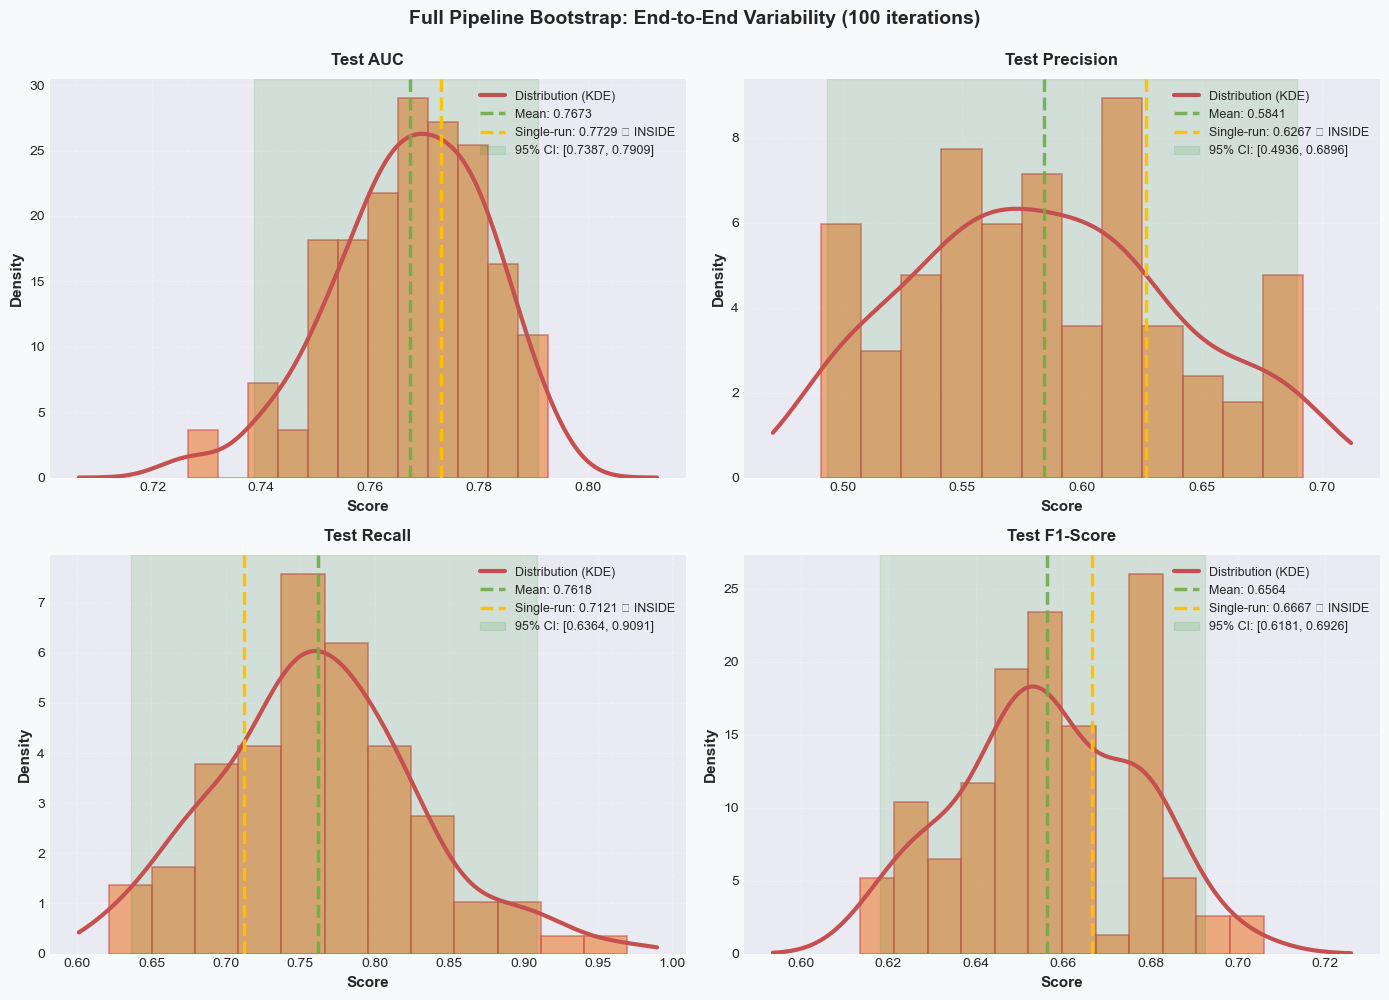

✓ Full pipeline bootstrap validation complete


In [87]:
print(f'\n{"="*80}')
print(f'FULL PIPELINE BOOTSTRAP VALIDATION')
print(f'{"="*80}')
print(f'\nThis runs the complete pipeline for each bootstrap sample:')
print(f'  1. Feature selection (top {TOP_N_FEATURES} features)')
print(f'  2. Hyperparameter tuning ({N_TRIALS} Optuna trials)')
print(f'  3. Threshold optimization')
print(f'  4. Test set evaluation')

# Set seed for reproducibility
np.random.seed(123)

N_BOOTSTRAP_FULL = 100  # Smaller number due to computational cost
pipeline_metrics = {
    'test_auc': [],
    'test_precision': [],
    'test_recall': [],
    'test_f1': [],
    'chosen_thresholds': [],
    'n_features_selected': [],
}

print(f'\nRunning {N_BOOTSTRAP_FULL} full pipeline bootstrap iterations...')
print('Progress: ', end='')

for b in range(N_BOOTSTRAP_FULL):
    if (b + 1) % 5 == 0:
        print(f'{b+1}', end=' ')
    
    # Bootstrap sample from training set with replacement
    boot_indices = np.random.choice(len(X_train_final), size=len(X_train_final), replace=True)
    X_boot = X_train_final.iloc[boot_indices]
    y_boot = y_train.iloc[boot_indices]
    
    # Step 1: Feature selection 
    fold_imp_boot = []
    for train_idx, val_idx in skf.split(X_boot, y_boot):
        X_tr, X_v = X_boot.iloc[train_idx], X_boot.iloc[val_idx]
        y_tr, y_v = y_boot.iloc[train_idx], y_boot.iloc[val_idx]
        model_imp = RandomForestClassifier(**baseline_params, class_weight='balanced',
                                           random_state=RANDOM_STATE, n_jobs=-1)
        model_imp.fit(X_tr, y_tr)
        perm = permutation_importance(model_imp, X_v, y_v, n_repeats=3, 
                                     random_state=RANDOM_STATE, scoring='roc_auc')
        fold_imp_boot.append(perm.importances_mean)
    
    mean_imp_boot = np.mean(fold_imp_boot, axis=0)
    perm_boot = pd.DataFrame({
        'Feature': X_boot.columns,
        'Importance': mean_imp_boot,
    }).sort_values('Importance', ascending=False)
    
    # Select top N features
    top_feat_boot = perm_boot.head(TOP_N_FEATURES)['Feature'].tolist()
    X_boot_sel = X_boot[top_feat_boot]
    X_test_sel = X_test_final[top_feat_boot]
    
    pipeline_metrics['n_features_selected'].append(len(top_feat_boot))
    
    # Step 2: Lightweight hyperparameter tuning (3 trials for speed)
    study_boot = optuna.create_study(direction='maximize', 
                                     sampler=TPESampler(seed=RANDOM_STATE + b))
    study_boot.optimize(
        lambda trial: optuna_objective(trial, X_boot_sel, y_boot, skf, LAM),
        n_trials=3, show_progress_bar=False,
    )
    params_boot = study_boot.best_params
    
    # Step 3: Fit model and find optimal threshold on bootstrap OOF
    oof_proba_boot = np.zeros(len(y_boot))
    for train_idx, val_idx in skf.split(X_boot_sel, y_boot):
        X_tr, X_v = X_boot_sel.iloc[train_idx], X_boot_sel.iloc[val_idx]
        y_tr = y_boot.iloc[train_idx]
        m_boot = build_rf(params_boot)
        m_boot.fit(X_tr, y_tr)
        oof_proba_boot[val_idx] = m_boot.predict_proba(X_v)[:, 1]
    
    # Find optimal threshold
    thresholds_boot = np.arange(0.05, 0.95, 0.05)
    f1s_boot = np.array([f1_score(y_boot, (oof_proba_boot >= t).astype(int), zero_division=0) 
                         for t in thresholds_boot])
    best_thresh_boot = thresholds_boot[np.argmax(f1s_boot)]
    pipeline_metrics['chosen_thresholds'].append(best_thresh_boot)
    
    # Step 4: Train final model and evaluate on test set
    model_final_boot = build_rf(params_boot)
    model_final_boot.fit(X_boot_sel, y_boot)
    
    y_proba_test_boot = model_final_boot.predict_proba(X_test_sel)[:, 1]
    y_pred_test_boot = (y_proba_test_boot >= best_thresh_boot).astype(int)
    
    pipeline_metrics['test_auc'].append(roc_auc_score(y_test, y_proba_test_boot))
    pipeline_metrics['test_precision'].append(precision_score(y_test, y_pred_test_boot, zero_division=0))
    pipeline_metrics['test_recall'].append(recall_score(y_test, y_pred_test_boot, zero_division=0))
    pipeline_metrics['test_f1'].append(f1_score(y_test, y_pred_test_boot, zero_division=0))

print('\n✓ Full pipeline bootstrap complete')

# Compute statistics
print(f'\n{"─"*80}')
print(f'Full Pipeline Bootstrap Results ({N_BOOTSTRAP_FULL} iterations)')
print(f'{"─"*80}')

metrics_names = ['test_auc', 'test_precision', 'test_recall', 'test_f1']
display_names = ['Test AUC', 'Test Precision', 'Test Recall', 'Test F1']

# Single-run values from original pipeline
single_run_full = {
    'test_auc': test_auc,
    'test_precision': prec_final,
    'test_recall': rec_final,
    'test_f1': f1_final,
}

print(f'\nDesign Choice Variability:')
print(f'  Thresholds chosen: Min={min(pipeline_metrics["chosen_thresholds"]):.2f}, '
      f'Max={max(pipeline_metrics["chosen_thresholds"]):.2f}, '
      f'Mean={np.mean(pipeline_metrics["chosen_thresholds"]):.2f}')
print(f'  Features selected: Min={min(pipeline_metrics["n_features_selected"])}, '
      f'Max={max(pipeline_metrics["n_features_selected"])}, '
      f'Mean={np.mean(pipeline_metrics["n_features_selected"]):.1f}')

for metric_key, display_name in zip(metrics_names, display_names):
    values = np.array(pipeline_metrics[metric_key])
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_lower = np.percentile(values, 2.5)
    ci_upper = np.percentile(values, 97.5)
    single_run_val = single_run_full.get(metric_key)
    in_ci = ci_lower <= single_run_val <= ci_upper if single_run_val is not None else None
    
    print(f'\n{display_name}:')
    print(f'  Single-run:  {single_run_val:.4f}' if single_run_val is not None else '')
    print(f'  Mean:        {mean_val:.4f}')
    print(f'  Std Dev:     {std_val:.4f}')
    print(f'  95% CI:      [{ci_lower:.4f}, {ci_upper:.4f}]')
    if single_run_val is not None:
        status = '✓ Within CI' if in_ci else '⚠ Outside CI'
        print(f'  Status:      {status}')

# Visualize
print(f'\n{"─"*80}')
print('Creating full pipeline bootstrap distribution plots...')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Full Pipeline Bootstrap: End-to-End Variability (100 iterations)', 
             fontsize=14, fontweight='bold', y=0.995)

metrics_to_plot_full = [
    ('test_auc', 'Test AUC', test_auc),
    ('test_precision', 'Test Precision', prec_final),
    ('test_recall', 'Test Recall', rec_final),
    ('test_f1', 'Test F1-Score', f1_final),
]

for idx, (metric_key, title, single_run_val) in enumerate(metrics_to_plot_full):
    ax = axes[idx // 2, idx % 2]
    values = pipeline_metrics[metric_key]
    
    # Histogram
    n, bins, patches = ax.hist(values, bins=12, color='#ED7D31', alpha=0.5, 
                                edgecolor='#C5504F', linewidth=1.2, density=True)
    
    for patch in patches:
        patch.set_facecolor('#ED7D31')
        patch.set_alpha(0.6)
    
    # KDE curve
    try:
        kde = gaussian_kde(values)
        x_range = np.linspace(min(values) - 0.02, max(values) + 0.02, 200)
        ax.plot(x_range, kde(x_range), color='#C5504F', linewidth=3, label='Distribution (KDE)')
    except:
        pass
    
    # Mean line
    mean_val = np.mean(values)
    ax.axvline(mean_val, color='#70AD47', linestyle='--', linewidth=2.5, 
               label=f'Mean: {mean_val:.4f}', alpha=0.9)
    
    # Single-run reference
    ci_lower = np.percentile(values, 2.5)
    ci_upper = np.percentile(values, 97.5)
    in_ci = ci_lower <= single_run_val <= ci_upper
    
    color = '#C5504F' if not in_ci else '#FFC000'
    linestyle = '-' if not in_ci else '--'
    linewidth = 3 if not in_ci else 2.5
    label_text = f'Single-run: {single_run_val:.4f} {"⚠ OUTSIDE" if not in_ci else "✓ INSIDE"}'
    ax.axvline(single_run_val, color=color, linestyle=linestyle, linewidth=linewidth, 
               label=label_text, alpha=0.95)
    
    # Shade CI
    ax.axvspan(ci_lower, ci_upper, alpha=0.1, color='green', 
               label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
    
    ax.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    
    legend = ax.legend(fontsize=9, loc='upper right', framealpha=0.95, edgecolor='#CCCCCC')
    legend.get_frame().set_facecolor('white')

plt.tight_layout()
plt.show()

print('✓ Full pipeline bootstrap validation complete')